In [12]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cervical_cancer.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Display basic information about the dataset
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [14]:
# Replace '?' with NaN
data.replace('?', np.nan, inplace=True)

# Check for missing values
print(data.isnull().sum())


Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [16]:
# Drop columns with more than 90% missing values
threshold = 0.9 * len(data)
data_cleaned = data.dropna(axis=1, thresh=threshold)

# Check the remaining columns
print(data_cleaned.isnull().sum())


Age                           0
Number of sexual partners    26
First sexual intercourse      7
Num of pregnancies           56
Smokes                       13
Smokes (years)               13
Smokes (packs/year)          13
STDs: Number of diagnosis     0
Dx:Cancer                     0
Dx:CIN                        0
Dx:HPV                        0
Dx                            0
Hinselmann                    0
Schiller                      0
Citology                      0
Biopsy                        0
dtype: int64


In [18]:
# Define columns to convert
numeric_columns = [
    "Number of sexual partners", "First sexual intercourse", 
    "Num of pregnancies", "Smokes", "Smokes (years)", "Smokes (packs/year)"
]

# Convert to float
for column in numeric_columns:
    data_cleaned[column] = data_cleaned[column].astype(float)

# Check data types
print(data_cleaned.dtypes)


Age                            int64
Number of sexual partners    float64
First sexual intercourse     float64
Num of pregnancies           float64
Smokes                       float64
Smokes (years)               float64
Smokes (packs/year)          float64
STDs: Number of diagnosis      int64
Dx:Cancer                      int64
Dx:CIN                         int64
Dx:HPV                         int64
Dx                             int64
Hinselmann                     int64
Schiller                       int64
Citology                       int64
Biopsy                         int64
dtype: object


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1458599115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column] = data_cleaned[column].astype(float)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1458599115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column] = data_cleaned[column].astype(float)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1458599115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

In [20]:
# Impute missing values for numeric columns with the median
for column in numeric_columns:
    data_cleaned[column].fillna(data_cleaned[column].median(), inplace=True)

# Verify if all missing values are addressed
print(data_cleaned.isnull().sum())


Age                          0
Number of sexual partners    0
First sexual intercourse     0
Num of pregnancies           0
Smokes                       0
Smokes (years)               0
Smokes (packs/year)          0
STDs: Number of diagnosis    0
Dx:Cancer                    0
Dx:CIN                       0
Dx:HPV                       0
Dx                           0
Hinselmann                   0
Schiller                     0
Citology                     0
Biopsy                       0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1357837248.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[column].fillna(data_cleaned[column].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1357837248.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[column].fillna(data_cleaned[col

In [22]:
# Check the cleaned dataset's structure and preview it
print(data_cleaned.info())
print(data_cleaned.head())

# Save the cleaned dataset for further use
data_cleaned.to_csv('cleaned_cervical_cancer.csv', index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        858 non-null    int64  
 1   Number of sexual partners  858 non-null    float64
 2   First sexual intercourse   858 non-null    float64
 3   Num of pregnancies         858 non-null    float64
 4   Smokes                     858 non-null    float64
 5   Smokes (years)             858 non-null    float64
 6   Smokes (packs/year)        858 non-null    float64
 7   STDs: Number of diagnosis  858 non-null    int64  
 8   Dx:Cancer                  858 non-null    int64  
 9   Dx:CIN                     858 non-null    int64  
 10  Dx:HPV                     858 non-null    int64  
 11  Dx                         858 non-null    int64  
 12  Hinselmann                 858 non-null    int64  
 13  Schiller                   858 non-null    int64  

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 1: Encode Categorical Variables
# Assuming binary columns like 'Dx:Cancer' are already numeric (0 or 1), we encode if necessary
categorical_columns = ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

# Verify if they need encoding
for col in categorical_columns:
    if data_cleaned[col].dtype == 'object':
        le = LabelEncoder()
        data_cleaned[col] = le.fit_transform(data_cleaned[col])

# Step 2: Normalize/Standardize Numeric Features
# Define numeric columns for normalization
numeric_columns = [
    "Age", "Number of sexual partners", "First sexual intercourse", 
    "Num of pregnancies", "Smokes", "Smokes (years)", "Smokes (packs/year)"
]

# Initialize the scaler
scaler = StandardScaler()

# Apply scaling
data_cleaned[numeric_columns] = scaler.fit_transform(data_cleaned[numeric_columns])

# Step 3: Split the Dataset
# Define features (X) and target variable (y)
X = data_cleaned.drop(['Biopsy'], axis=1)  # Assuming 'Biopsy' is the target
y = data_cleaned['Biopsy']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inspect the shapes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


Training features shape: (686, 15)
Testing features shape: (172, 15)
Training labels shape: (686,)
Testing labels shape: (172,)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\17305432.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[numeric_columns] = scaler.fit_transform(data_cleaned[numeric_columns])


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

# Step 1: Encode Categorical Variables
categorical_columns = ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

# Encode categorical columns if necessary
for col in categorical_columns:
    if data_cleaned[col].dtype == 'object':
        le = LabelEncoder()
        data_cleaned[col] = le.fit_transform(data_cleaned[col])

# Step 2: Normalize/Standardize Numeric Features
# Define numeric columns
numeric_columns = [
    "Age", "Number of sexual partners", "First sexual intercourse", 
    "Num of pregnancies", "Smokes", "Smokes (years)", "Smokes (packs/year)"
]

# Initialize and apply the scaler
scaler = StandardScaler()
data_cleaned[numeric_columns] = scaler.fit_transform(data_cleaned[numeric_columns])

# Step 3: Detect and Remove Near-Zero Variance Columns
# Separate features (X) and target (y)
X = data_cleaned.drop(['Biopsy'], axis=1)  # Assuming 'Biopsy' is the target
y = data_cleaned['Biopsy']

# Initialize VarianceThreshold and fit to the data
selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

# Get the list of columns to keep
columns_to_keep = X.columns[selector.get_support()]

# Reduce X to only include selected columns
X = X[columns_to_keep]

print("Removed columns due to near-zero variance:", set(data_cleaned.columns) - set(columns_to_keep) - {'Biopsy'})

# Step 4: Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inspect shapes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


Removed columns due to near-zero variance: set()
Training features shape: (686, 15)
Testing features shape: (172, 15)
Training labels shape: (686,)
Testing labels shape: (172,)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\2497634506.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned[numeric_columns] = scaler.fit_transform(data_cleaned[numeric_columns])


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt


                Age  Number of sexual partners  First sexual intercourse  \
count  8.580000e+02               8.580000e+02              8.580000e+02   
mean  -1.656277e-17              -2.277381e-17             -8.281384e-18   
std    1.000583e+00               1.000583e+00              1.000583e+00   
min   -1.627284e+00              -9.196100e-01             -2.507060e+00   
25%   -8.030752e-01              -3.112635e-01             -7.151094e-01   
50%   -2.143546e-01              -3.112635e-01              1.670816e-03   
75%    6.098541e-01               2.970830e-01              3.600609e-01   
max    6.732547e+00               1.550575e+01              5.377522e+00   

       Num of pregnancies        Smokes  Smokes (years)  Smokes (packs/year)  \
count        8.580000e+02  8.580000e+02    8.580000e+02         8.580000e+02   
mean        -3.312554e-17  2.587932e-17   -4.140692e-18        -3.726623e-17   
std          1.000583e+00  1.000583e+00    1.000583e+00         1.000583e+0

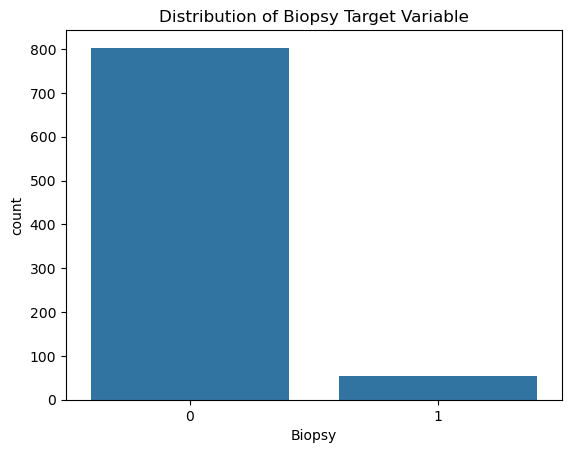

In [30]:
# Basic statistics
print(data_cleaned.describe())

# Check for class imbalance in the target variable
print(data_cleaned['Biopsy'].value_counts())

# Visualize the target variable distribution
sns.countplot(x='Biopsy', data=data_cleaned)
plt.title('Distribution of Biopsy Target Variable')
plt.show()


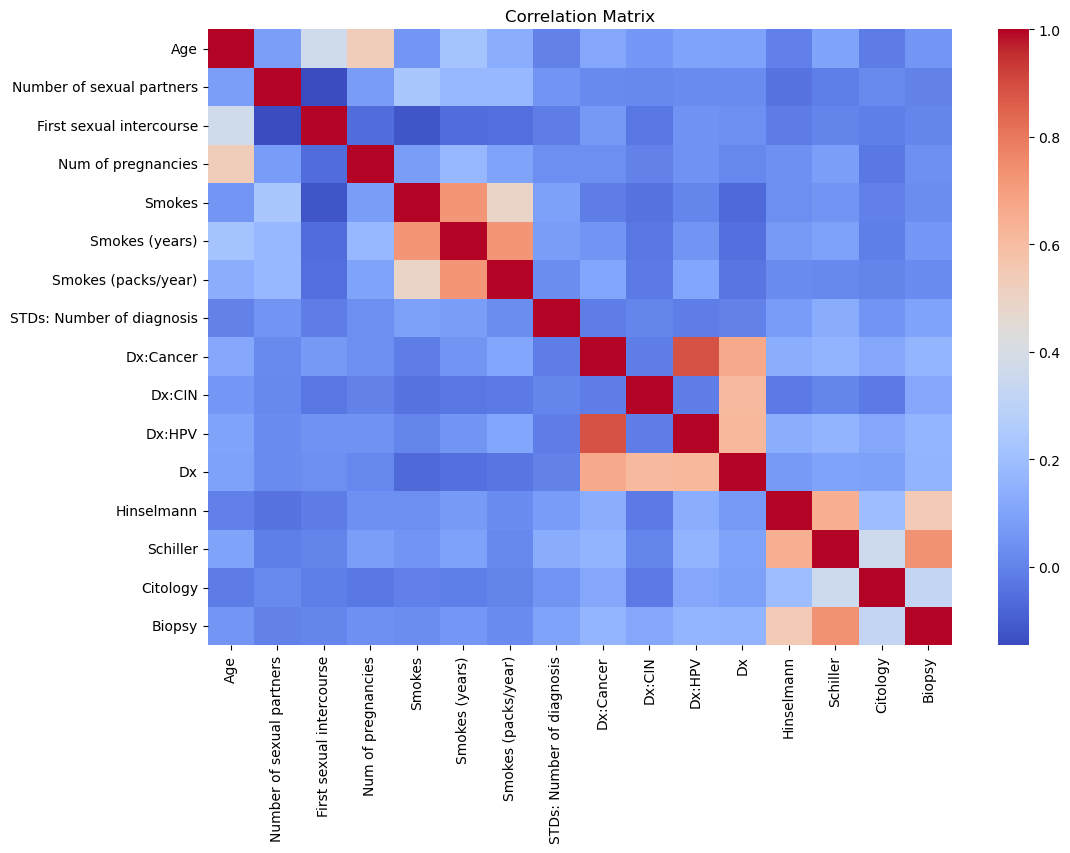

Strong correlations with Biopsy:
 Biopsy                       1.000000
Schiller                     0.733204
Hinselmann                   0.547417
Citology                     0.327466
Dx:Cancer                    0.160905
Dx:HPV                       0.160905
Dx                           0.157607
Dx:CIN                       0.113172
STDs: Number of diagnosis    0.097449
Smokes (years)               0.061204
Name: Biopsy, dtype: float64


In [32]:
# Plot the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = data_cleaned.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Highlight the strongest correlations with the target variable
target_corr = correlation_matrix['Biopsy'].sort_values(ascending=False)
print("Strong correlations with Biopsy:\n", target_corr.head(10))


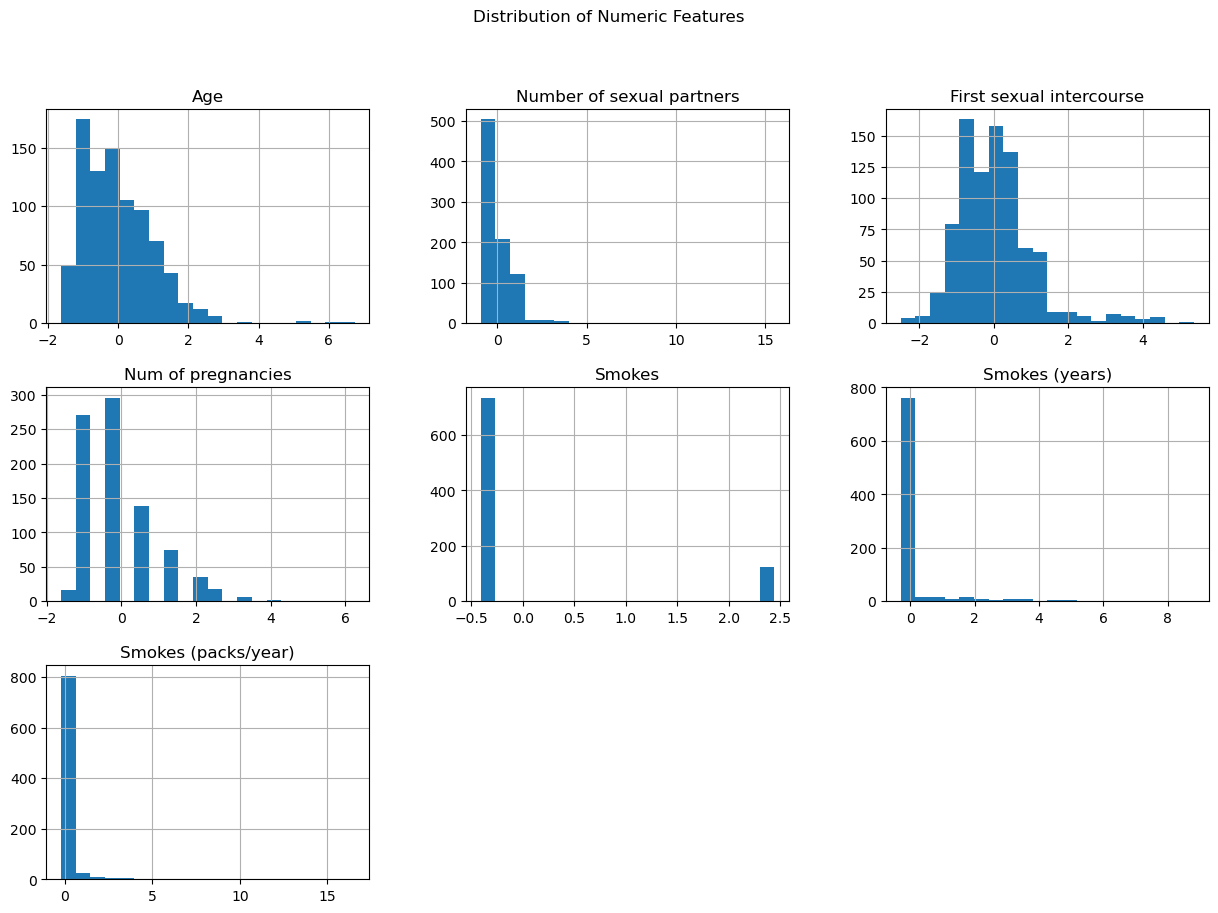

In [34]:
# Plot histograms for numeric columns
numeric_columns = [
    "Age", "Number of sexual partners", "First sexual intercourse", 
    "Num of pregnancies", "Smokes", "Smokes (years)", "Smokes (packs/year)"
]

data_cleaned[numeric_columns].hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.show()


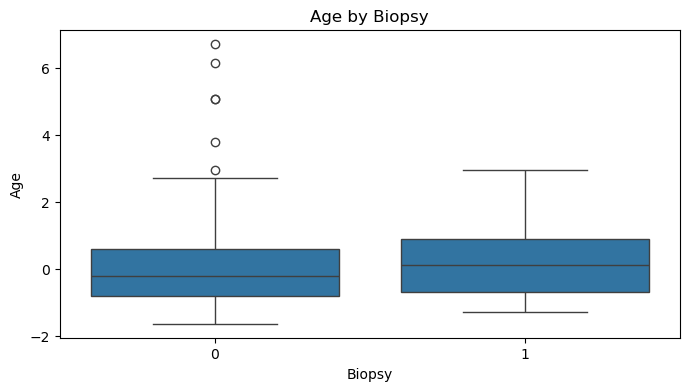

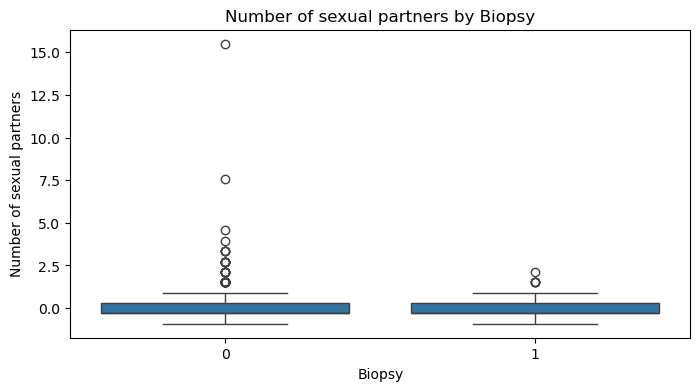

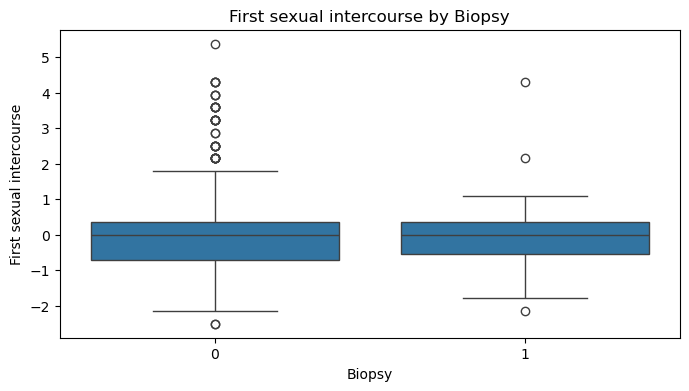

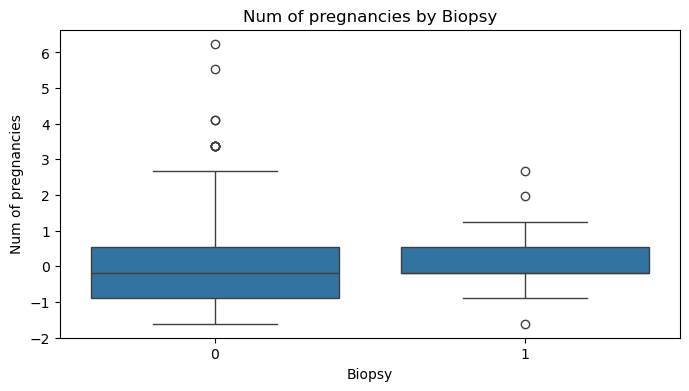

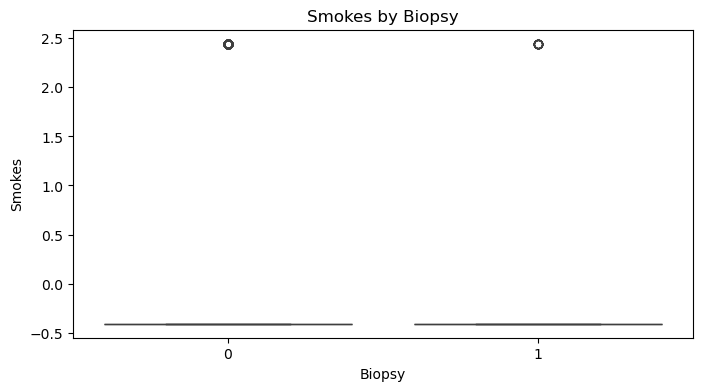

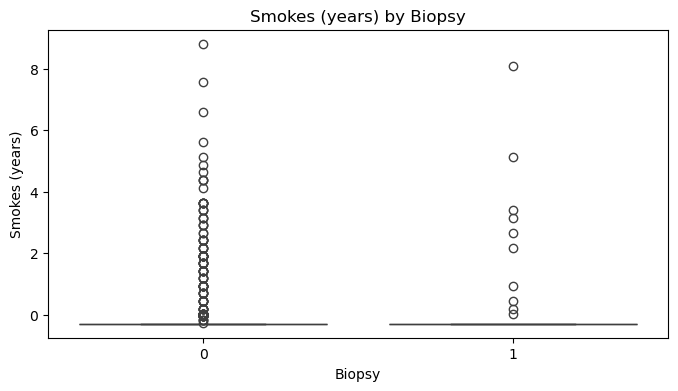

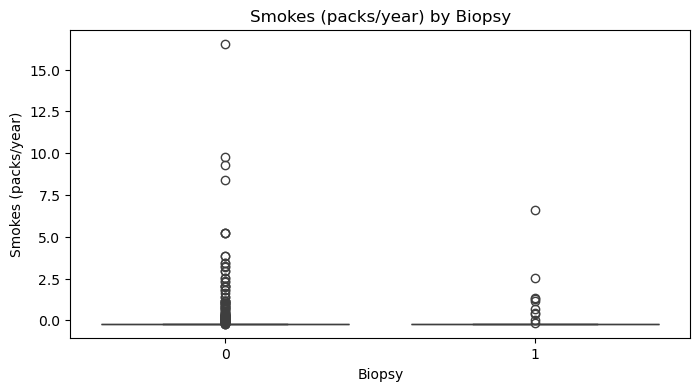

In [36]:
# Boxplots of numeric features grouped by Biopsy
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Biopsy', y=col, data=data_cleaned)
    plt.title(f'{col} by Biopsy')
    plt.show()


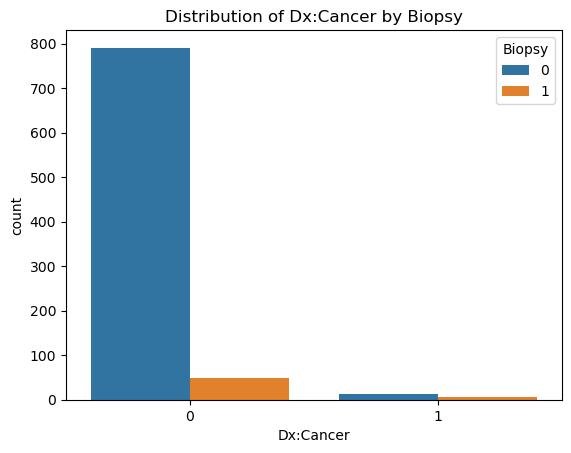

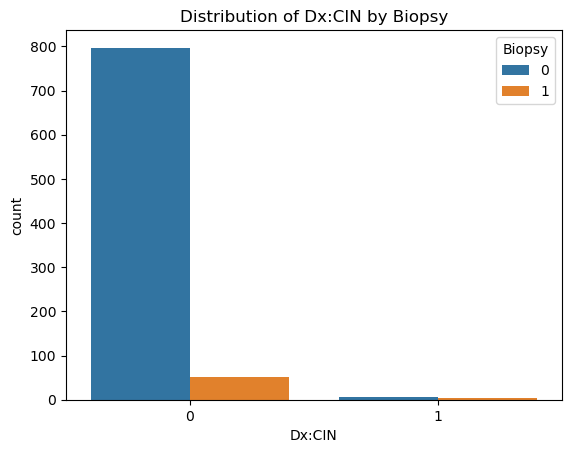

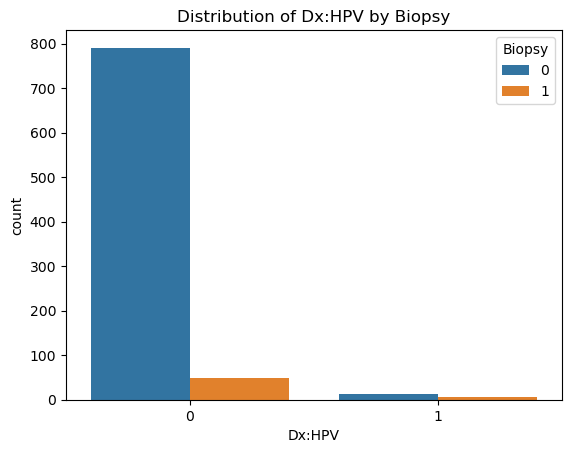

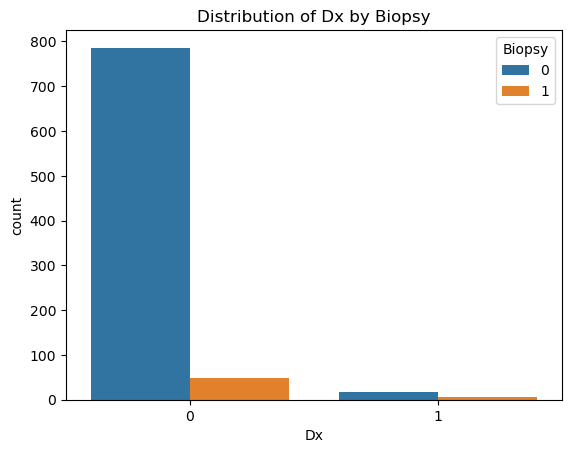

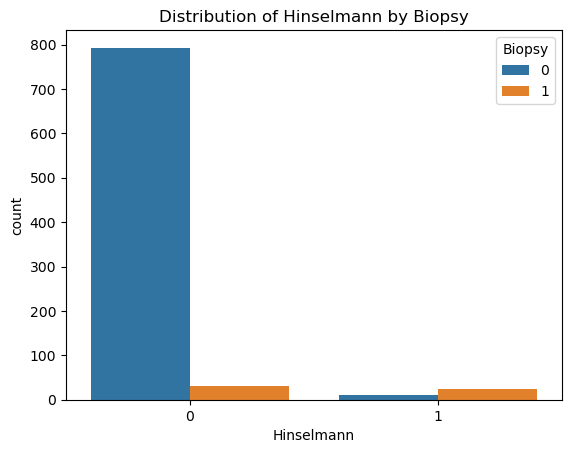

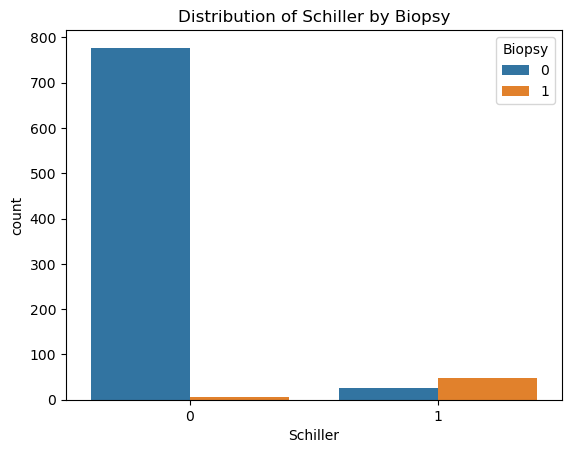

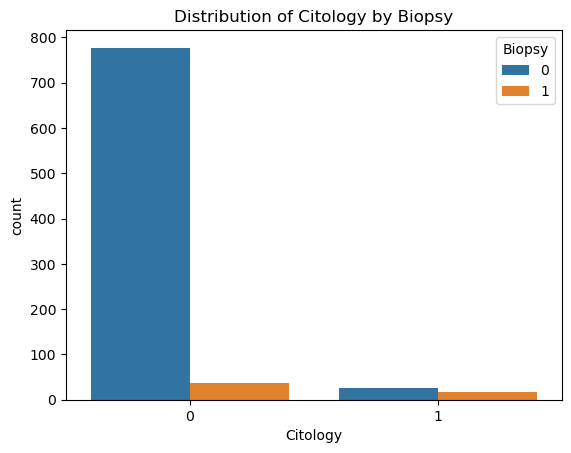

In [38]:
# Categorical feature distributions
categorical_columns = ['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology']

for col in categorical_columns:
    sns.countplot(x=col, hue='Biopsy', data=data_cleaned)
    plt.title(f'Distribution of {col} by Biopsy')
    plt.show()


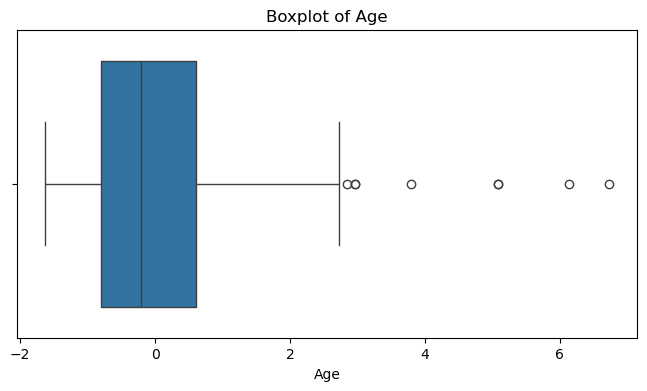

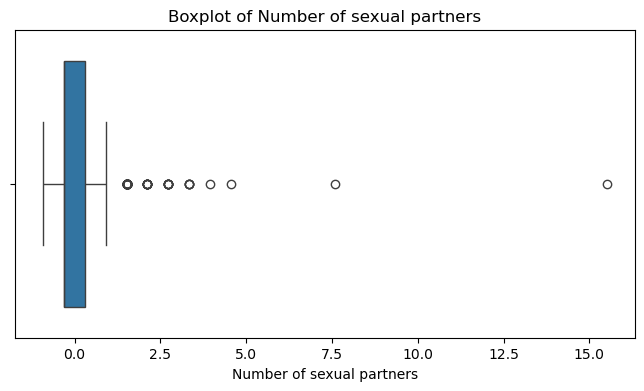

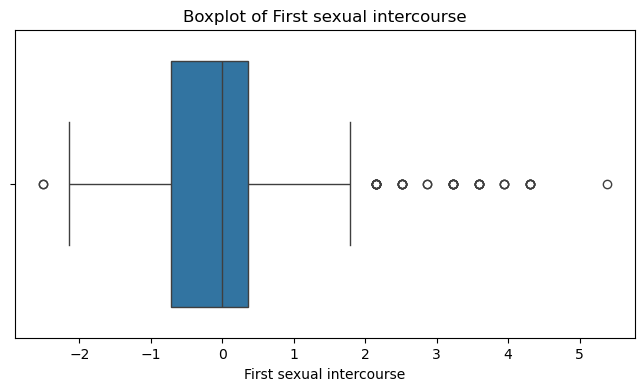

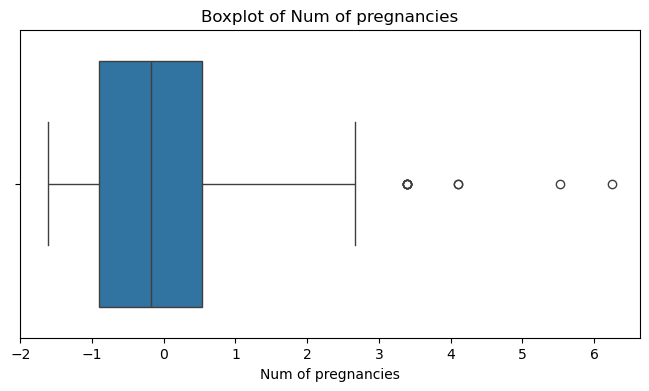

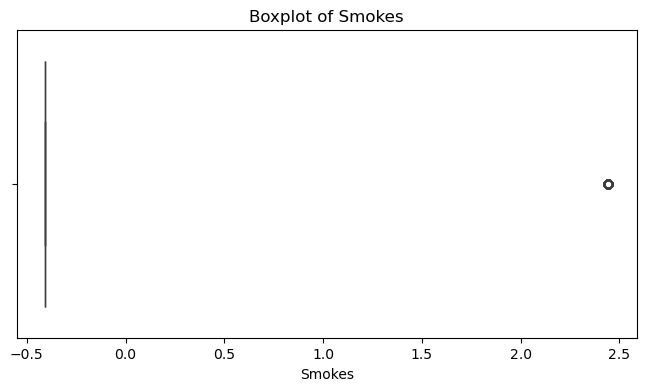

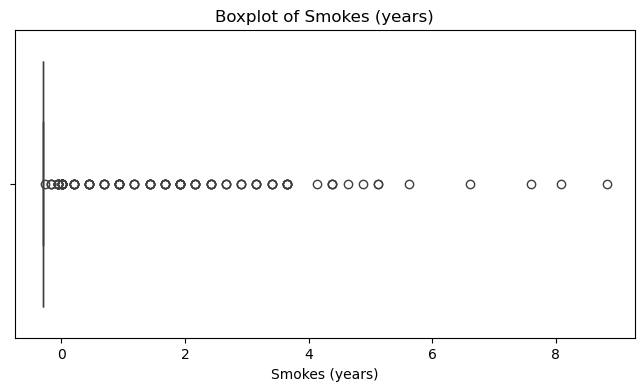

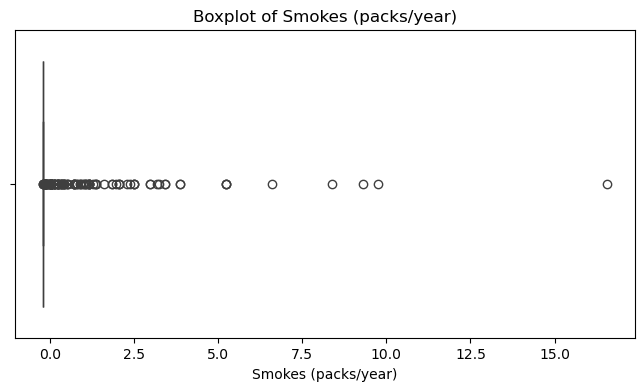

In [40]:
# Boxplots to identify potential outliers
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_cleaned[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Summary Statistics for Age:
count    8.580000e+02
mean    -1.656277e-17
std      1.000583e+00
min     -1.627284e+00
25%     -8.030752e-01
50%     -2.143546e-01
75%      6.098541e-01
max      6.732547e+00
Name: Age, dtype: float64


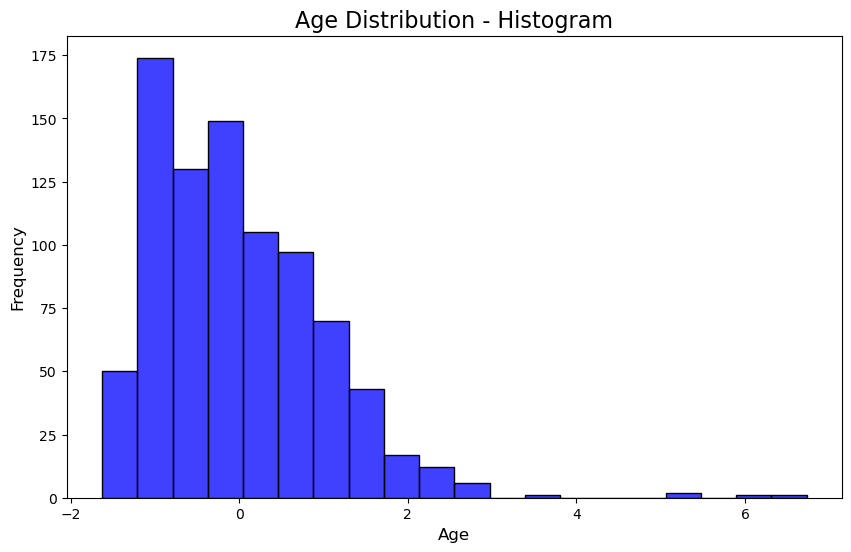

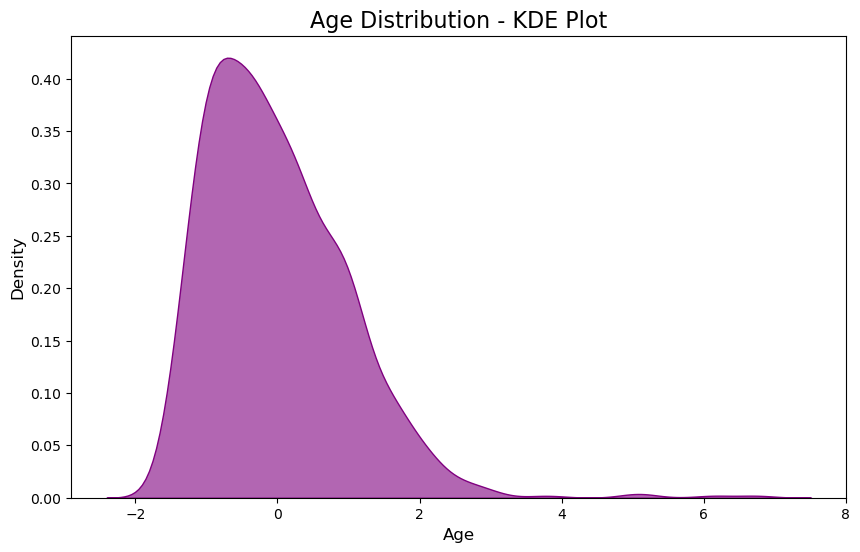

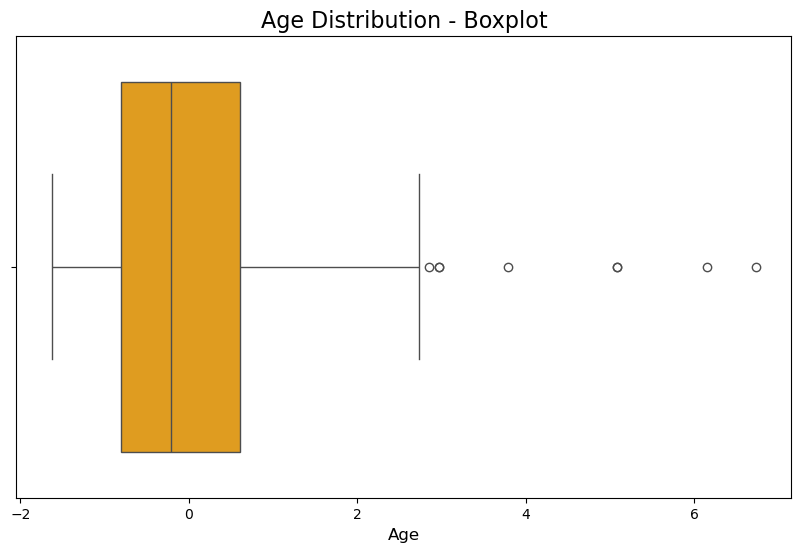

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\1752673449.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Biopsy', y='Age', data=data_cleaned, palette='Set2')


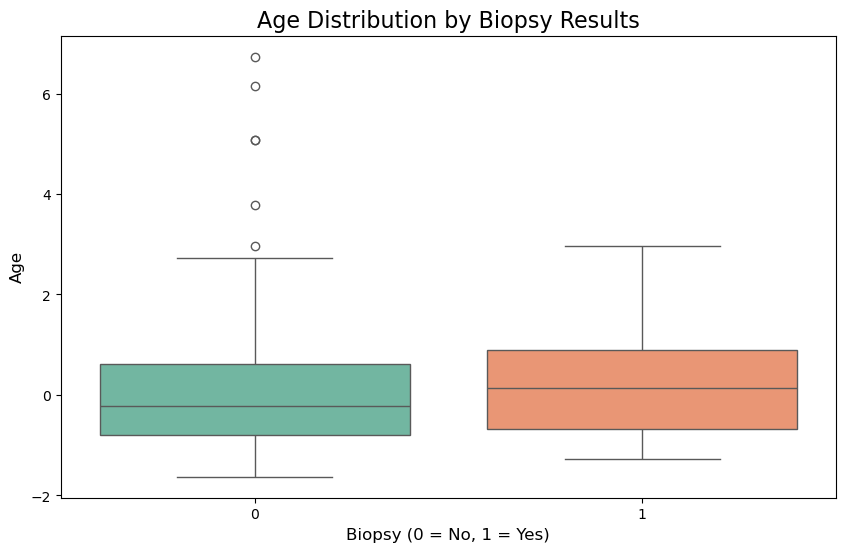

In [42]:
# Step 1: Summary Statistics
age_summary = data_cleaned['Age'].describe()
print("Summary Statistics for Age:")
print(age_summary)

# Step 2: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data_cleaned['Age'], bins=20, kde=False, color='blue')
plt.title('Age Distribution - Histogram', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data_cleaned['Age'], fill=True, color='purple', alpha=0.6)
plt.title('Age Distribution - KDE Plot', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_cleaned['Age'], color='orange')
plt.title('Age Distribution - Boxplot', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.xticks(fontsize=10)
plt.show()

# Step 3: Group Analysis (Optional)
# For example, age distribution by biopsy results
plt.figure(figsize=(10, 6))
sns.boxplot(x='Biopsy', y='Age', data=data_cleaned, palette='Set2')
plt.title('Age Distribution by Biopsy Results', fontsize=16)
plt.xlabel('Biopsy (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


In [44]:
# Define age groups
bins = [0, 19, 29, 39, 49, 59, 69, 100]  # You can adjust these as needed
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

# Filter for female patients if needed (assuming there's a 'Gender' column)
# data_female = data[data['Gender'] == 'Female']  # Adjust as necessary


In [46]:
# Group by the new 'Age Group' and count occurrences
age_distribution = data['Age Group'].value_counts().sort_index()

# Display the result
print(age_distribution)


Age Group
<20      135
20-29    405
30-39    244
40-49     63
50-59      6
60-69      1
70+        4
Name: count, dtype: int64


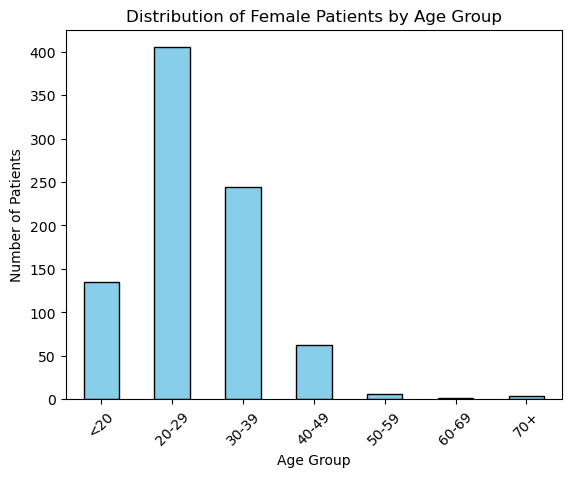

In [48]:
import matplotlib.pyplot as plt

# Plot the age distribution
age_distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Female Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()


In [50]:
# Group by 'Age Group' and 'Biopsy Result' and count occurrences
age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy Result']).size().unstack(fill_value=0)

# Display the result
print(age_biopsy_distribution)


KeyError: 'Biopsy Result'

In [54]:
import pandas as pd

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Display the first few rows and columns to understand its structure
print(data.head())
print(data.columns)


   Age  Number of sexual partners  First sexual intercourse  \
0   18                        4.0                      15.0   
1   15                        1.0                      14.0   
2   34                        1.0                      17.0   
3   52                        5.0                      16.0   
4   46                        3.0                      21.0   

   Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                 1.0     0.0             0.0                  0.0   
1                 1.0     0.0             0.0                  0.0   
2                 1.0     0.0             0.0                  0.0   
3                 4.0     1.0            37.0                 37.0   
4                 4.0     0.0             0.0                  0.0   

   STDs: Number of diagnosis  Dx:Cancer  Dx:CIN  Dx:HPV  Dx  Hinselmann  \
0                          0          0       0       0   0           0   
1                          0          0       0   

In [56]:
# Define age groups
bins = [0, 19, 29, 39, 49, 59, 69, 100]  # Adjust these ranges as needed
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)


In [58]:
# Group by 'Age Group' and 'Biopsy Result' and count occurrences
age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy Result']).size().unstack(fill_value=0)

# Display the result
print(age_biopsy_distribution)


KeyError: 'Biopsy Result'

In [60]:
age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy Result']).size().unstack(fill_value=0)

KeyError: 'Biopsy Result'

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx',
       'Hinselmann', 'Schiller', 'Citology', 'Biopsy'],
      dtype='object')
Biopsy
0    803
1     55
Name: count, dtype: int64
Biopsy       0   1
Age Group         
<20        131   4
20-29      377  28
30-39      227  17
40-49       59   4
50-59        4   2
60-69        1   0
70+          4   0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\2736497051.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy']).size().unstack(fill_value=0)


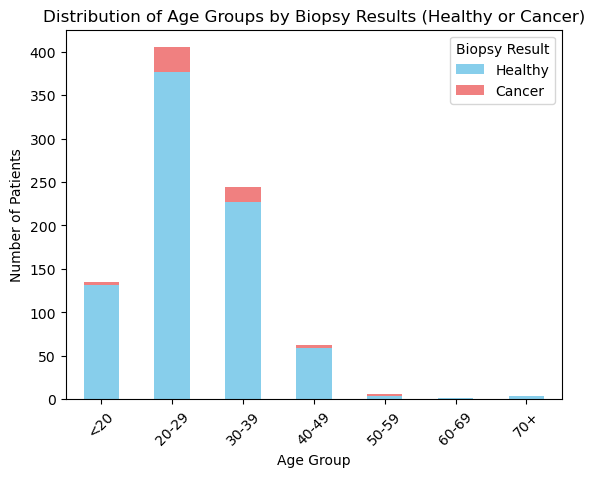

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Check the columns to confirm the relevant columns for age and biopsy results
print(data.columns)

# Define age groups (you can adjust the bins and labels as needed)
bins = [0, 19, 29, 39, 49, 59, 69, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

# Check if there’s a 'Biopsy Result' column (or adjust accordingly to your dataset)
# Assuming there's a 'Biopsy' column with 'Healthy' or 'Cancer' as possible values
# You can replace 'Biopsy' with the actual column name from your dataset
biopsy_results = data['Biopsy'].value_counts()  # This checks the distribution of biopsy results
print(biopsy_results)

# Now, group by both age group and biopsy result, then count the occurrences
age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy']).size().unstack(fill_value=0)

# Display the resulting distribution
print(age_biopsy_distribution)

# Plotting the distribution
age_biopsy_distribution.plot(kind='bar', stacked=True, color=['skyblue', 'lightcoral'])
plt.title('Distribution of Age Groups by Biopsy Results (Healthy or Cancer)')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Biopsy Result', loc='upper right', labels=['Healthy', 'Cancer'])
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15444\801337839.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy']).size().unstack(fill_value=0)


Biopsy              0          1
Age Group                       
<20         97.037037   2.962963
20-29       93.086420   6.913580
30-39       93.032787   6.967213
40-49       93.650794   6.349206
50-59       66.666667  33.333333
60-69      100.000000   0.000000
70+        100.000000   0.000000


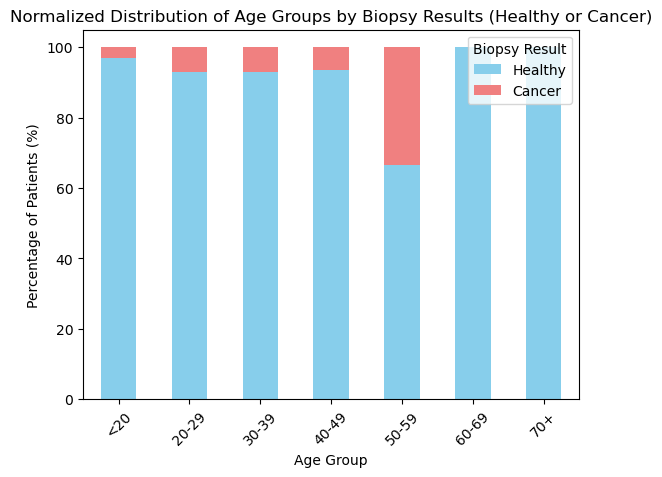

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Define age groups (you can adjust the bins and labels as needed)
bins = [0, 19, 29, 39, 49, 59, 69, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
data['Age Group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

# Group by both age group and biopsy result, then count the occurrences
age_biopsy_distribution = data.groupby(['Age Group', 'Biopsy']).size().unstack(fill_value=0)

# Normalize the counts to percentages (by dividing each value by the row sum)
age_biopsy_distribution_normalized = age_biopsy_distribution.div(age_biopsy_distribution.sum(axis=1), axis=0) * 100

# Display the normalized distribution (in percentages)
print(age_biopsy_distribution_normalized)

# Plotting the normalized distribution as percentages
age_biopsy_distribution_normalized.plot(kind='bar', stacked=True, color=['skyblue', 'lightcoral'])
plt.title('Normalized Distribution of Age Groups by Biopsy Results (Healthy or Cancer)')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Patients (%)')
plt.xticks(rotation=45)
plt.legend(title='Biopsy Result', loc='upper right', labels=['Healthy', 'Cancer'])
plt.show()


In [66]:
counts

NameError: name 'counts' is not defined

Explained variance ratio for the first 10 components:
[0.19034008 0.15453921 0.1299756  0.0964161  0.08040856 0.06596619
 0.06057229 0.05582845 0.04963173 0.03079273]

Cumulative explained variance for the first 10 components:
[0.19034008 0.3448793  0.4748549  0.571271   0.65167956 0.71764575
 0.77821804 0.83404649 0.88367821 0.91447095]


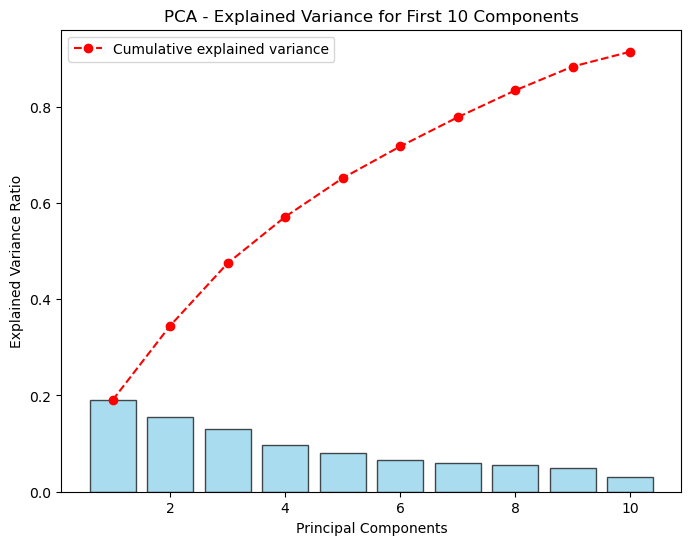

In [68]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Preprocessing: Select only numerical columns (exclude non-numeric columns)
# If you have specific numerical columns to use, you can filter those
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Apply PCA to extract the first 10 components
pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_data)

# Explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_

# Display the explained variance ratio for each of the first 10 components
print("Explained variance ratio for the first 10 components:")
print(explained_variance_ratio)

# Cumulative explained variance (to see how much total variance is explained)
cumulative_explained_variance = explained_variance_ratio.cumsum()

print("\nCumulative explained variance for the first 10 components:")
print(cumulative_explained_variance)

# Visualize the explained variance
plt.figure(figsize=(8, 6))

# Plot the explained variance of the first 10 components
plt.bar(range(1, 11), explained_variance_ratio, alpha=0.7, color='skyblue', edgecolor='black')
plt.plot(range(1, 11), cumulative_explained_variance, marker='o', color='red', linestyle='--', label='Cumulative explained variance')

plt.title('PCA - Explained Variance for First 10 Components')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.show()


Percent Variance for each component:
[19.03400842 15.45392122 12.99756003  9.64160993  8.04085608  6.59661894
  6.05722933  5.58284481  4.96317259  3.07927328]

Change in Variance between consecutive components:
[0, -3.5800872067948752, -2.456361185029662, -3.355950100291441, -1.6007538542370696, -1.4442371385878037, -0.5393896039634134, -0.47438452165842193, -0.6196722262229537, -1.8838993069925034]


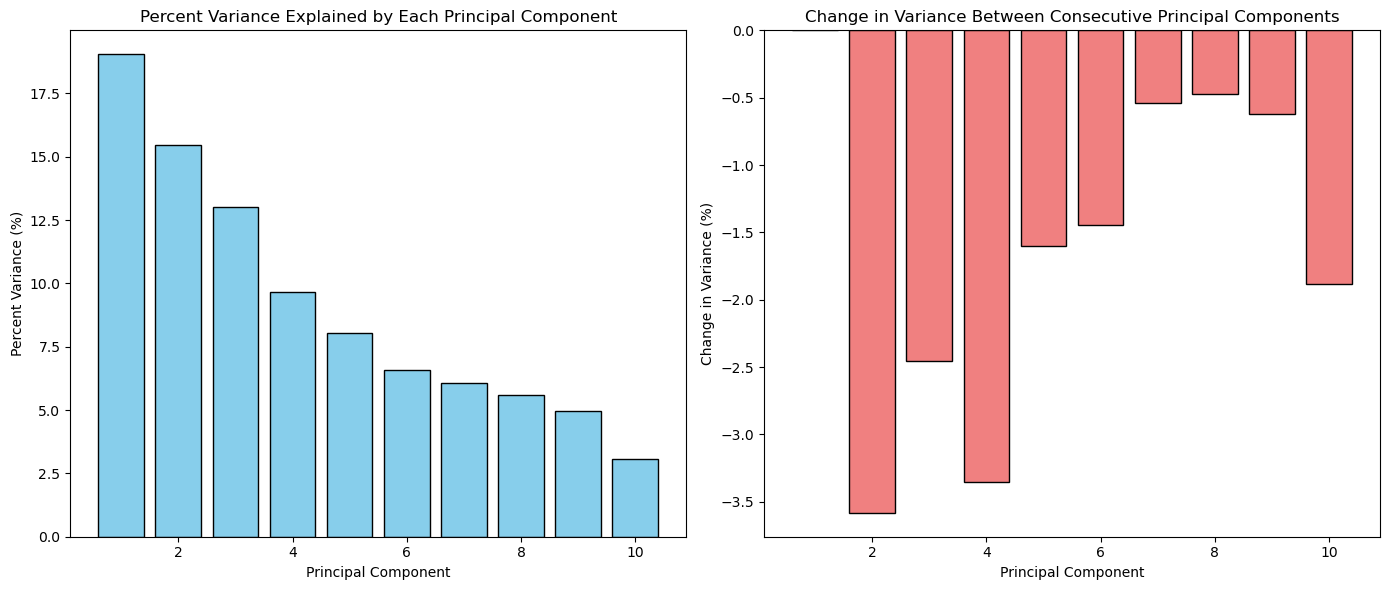

In [70]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Preprocessing: Select only numerical columns (exclude non-numeric columns)
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Apply PCA to extract the first 10 components
pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_data)

# Explained variance ratio for each component
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate the percent variance
percent_variance = explained_variance_ratio * 100

# Calculate the change in variance between consecutive components
change_in_variance = [0] + [percent_variance[i] - percent_variance[i - 1] for i in range(1, len(percent_variance))]

# Display the results
print("Percent Variance for each component:")
print(percent_variance)

print("\nChange in Variance between consecutive components:")
print(change_in_variance)

# Visualize Percent Variance and Change in Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the percent variance for each principal component
axes[0].bar(range(1, 11), percent_variance, color='skyblue', edgecolor='black')
axes[0].set_title('Percent Variance Explained by Each Principal Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Percent Variance (%)')

# Plot the change in variance between consecutive components
axes[1].bar(range(1, 11), change_in_variance, color='lightcoral', edgecolor='black')
axes[1].set_title('Change in Variance Between Consecutive Principal Components')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Change in Variance (%)')

plt.tight_layout()
plt.show()


Class distribution before balancing:
Biopsy
0    562
1     38
Name: count, dtype: int64

Class distribution after balancing (SMOTE):
Biopsy
1    562
0    562
Name: count, dtype: int64


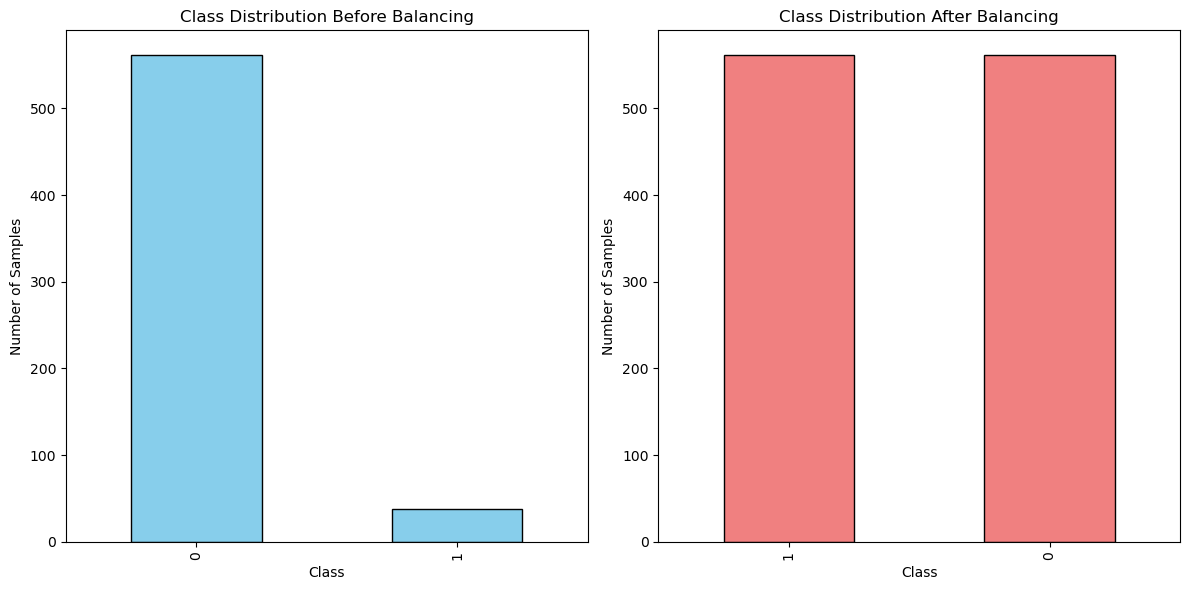

In [76]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Assume 'Target' is the target variable (update this to the correct target column)
X = data.drop(columns=['Biopsy'])  # Features (excluding target variable)
y = data['Biopsy']  # Target variable

# Step 1: Split the data into training (70%), validation (15%), and testing (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Check class distribution before balancing
print("Class distribution before balancing:")
print(y_train.value_counts())

# Step 2: Address Class Imbalance using SMOTE (Oversampling minority class)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check class distribution after balancing
print("\nClass distribution after balancing (SMOTE):")
print(pd.Series(y_train_res).value_counts())

# Optional: Plot the class distribution before and after balancing
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before balancing
y_train.value_counts().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Class Distribution Before Balancing')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')

# After balancing (SMOTE)
pd.Series(y_train_res).value_counts().plot(kind='bar', color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Class Distribution After Balancing')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# Now you can use the resampled data (X_train_res, y_train_res) for model training


In [80]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Assume 'Target' is the target variable (update this to the correct target column)
X = data.drop(columns=['Age'])  # Features (excluding target variable)
y = data['Age']  # Target variable

# Step 1: Split the data into training (70%), validation (15%), and testing (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Check class distribution before balancing
print("Class distribution before balancing:")
print(y_train.value_counts())

# Step 2: Address Class Imbalance using SMOTE (Oversampling minority class)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check class distribution after balancing
print("\nClass distribution after balancing (SMOTE):")
print(pd.Series(y_train_res).value_counts())

# Optional: Plot the class distribution before and after balancing
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Before balancing
y_train.value_counts().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Class Distribution Before Balancing')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')

# After balancing (SMOTE)
pd.Series(y_train_res).value_counts().plot(kind='bar', color='lightcoral', edgecolor='black', ax=axes[1])
axes[1].set_title('Class Distribution After Balancing')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

# Now you can use the resampled data (X_train_res, y_train_res) for model training


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [82]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Update with your actual file path
data = pd.read_csv(file_path)

# Step 2: Separate features (X) and target variable (y)
# Assume 'Target' is the column name of the target variable
X = data.drop(columns=['Biopsy'])  # Features (excluding the target variable)
y = data['Biopsy']  # Target variable

# Step 3: Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 4: Calculate dimensions
# Training dimensions
train_samples = X_train.shape[0]
train_features = X_train.shape[1]
# Testing dimensions
test_samples = X_test.shape[0]
test_features = X_test.shape[1]

# Step 5: Calculate percentages
total_samples = train_samples + test_samples
train_percentage = (train_samples / total_samples) * 100
test_percentage = (test_samples / total_samples) * 100

# Step 6: Display results
print("Training Dimensions:")
print(f"Samples: {train_samples}, Features: {train_features}")

print("\nTesting Dimensions:")
print(f"Samples: {test_samples}, Features: {test_features}")

print("\nPercentage Split:")
print(f"Training Percentage: {train_percentage:.2f}%")
print(f"Testing Percentage: {test_percentage:.2f}%")


Training Dimensions:
Samples: 600, Features: 15

Testing Dimensions:
Samples: 258, Features: 15

Percentage Split:
Training Percentage: 69.93%
Testing Percentage: 30.07%


In [84]:
# Control Parameters
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load data
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model with control parameters
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=5,           # Maximum tree depth
    min_samples_split=10,  # Minimum samples for a split
    min_samples_leaf=5,    # Minimum samples at a leaf
    random_state=42        # Seed for reproducibility
)

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate the model
accuracy = rf_model.score(X_test, y_test)
print(f"Random Forest Accuracy: {accuracy:.2f}")


Random Forest Accuracy: 1.00


In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load data
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model with control parameters
xgb_model = XGBClassifier(
    learning_rate=0.1,     # Learning rate
    n_estimators=100,      # Number of boosting rounds
    max_depth=3,           # Maximum depth of trees
    subsample=0.8,         # Subsample ratio
    colsample_bytree=0.8,  # Feature subsampling
    random_state=42        # Seed for reproducibility
)

# Train the model
xgb_model.fit(X_train, y_train)

# Evaluate the model
accuracy = xgb_model.score(X_test, y_test)
print(f"XGBoost Accuracy: {accuracy:.2f}")


XGBoost Accuracy: 1.00


In [90]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=42)

# Define model with control parameters
kmeans = KMeans(
    n_clusters=4,   # Number of clusters
    init='k-means++',  # Initialization method
    max_iter=300,    # Maximum iterations
    n_init=10,       # Number of initializations
    random_state=42  # Seed for reproducibility
)

# Train the model
kmeans.fit(X)

# Get cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

print(f"Cluster Centers: {centers}")


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Cluster Centers: [[-2.58917359  8.99638198]
 [-6.85598962 -6.85528354]
 [ 4.67904187  2.00748322]
 [-8.83518914  7.25750993]]


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load data
data = load_iris()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define model with control parameters
log_reg = LogisticRegression(
    penalty='l2',        # Regularization type
    C=1.0,               # Regularization strength
    solver='lbfgs',      # Optimization solver
    max_iter=1000        # Maximum iterations
)

# Train the model
log_reg.fit(X_train, y_train)

# Evaluate the model
accuracy = log_reg.score(X_test, y_test)
print(f"Logistic Regression Accuracy: {accuracy:.2f}")


Logistic Regression Accuracy: 1.00


In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Step 1: Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Assume 'Target' is the target variable (binary classification)
# Step 2: Separate features (X) and target variable (y)
X = data.drop(columns=['Biopsy'])  # Features
y = data['Biopsy']  # Target

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 4: Add a constant column to X (required for statsmodels GLM)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Step 5: Fit the GLM (logistic regression as an example)
glm_model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial())
glm_results = glm_model.fit()

# Display the model summary
print(glm_results.summary())

# Step 6: Make predictions
# Predicted probabilities
y_train_pred_prob = glm_results.predict(X_train_const)
y_test_pred_prob = glm_results.predict(X_test_const)

# Convert probabilities to binary predictions (using a threshold of 0.5)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

# Step 7: Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_test_pred_prob)

# Classification report
classification_rep = classification_report(y_test, y_test_pred)

print("\nModel Evaluation:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")
print("\nClassification Report:")
print(classification_rep)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Biopsy   No. Observations:                  600
Model:                            GLM   Df Residuals:                      584
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -44.490
Date:                Wed, 11 Dec 2024   Deviance:                       88.980
Time:                        00:41:36   Pearson chi2:                     564.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2766
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Step 1: Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Assume 'Target' is the binary target variable (0 or 1)
# Step 2: Separate features (X) and target variable (y)
X = data.drop(columns=['Biopsy'])  # Features
y = data['Biopsy']  # Target

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 4: Standardize the features
# SVMs are sensitive to feature scales; standardizing improves performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train the SVM model
# Using a radial basis function (RBF) kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Step 6: Make predictions
# Predict class labels
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Predict probabilities (for ROC-AUC calculation)
y_test_pred_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# Step 7: Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Classification Report
classification_rep = classification_report(y_test, y_test_pred)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_test_pred_prob)

# Step 8: Display results
print("Model Evaluation:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_rep)
print(f"ROC-AUC Score: {roc_auc:.2f}")


Model Evaluation:
Training Accuracy: 0.98
Testing Accuracy: 0.94

Confusion Matrix:
[[235   6]
 [  9   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       241
           1       0.57      0.47      0.52        17

    accuracy                           0.94       258
   macro avg       0.77      0.72      0.74       258
weighted avg       0.94      0.94      0.94       258

ROC-AUC Score: 0.88


In [100]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Assume 'Target' is the target variable (continuous for regression)
# Step 2: Separate features (X) and target variable (y)
X = data.drop(columns=['Biopsy'])  # Features
y = data['Biopsy']  # Target

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Standardize the features
# ElasticNet is sensitive to the scale of input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train the ElasticNet model with cross-validation
elastic_net_model = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 1],  # Values between 0 (Ridge) and 1 (Lasso)
    alphas=[0.01, 0.1, 1, 10],   # Regularization strength
    cv=5,                         # Number of cross-validation folds
    random_state=42
)
elastic_net_model.fit(X_train_scaled, y_train)

# Step 6: Best hyperparameters
print("Best Alpha:", elastic_net_model.alpha_)
print("Best L1 Ratio:", elastic_net_model.l1_ratio_)

# Step 7: Make predictions
y_train_pred = elastic_net_model.predict(X_train_scaled)
y_test_pred = elastic_net_model.predict(X_test_scaled)

# Step 8: Evaluate the model
# Mean Squared Error (MSE)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R-squared (R2)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Display results
print("\nModel Evaluation:")
print(f"Training MSE: {train_mse:.2f}")
print(f"Testing MSE: {test_mse:.2f}")
print(f"Training R2 Score: {train_r2:.2f}")
print(f"Testing R2 Score: {test_r2:.2f}")


Best Alpha: 0.01
Best L1 Ratio: 1.0

Model Evaluation:
Training MSE: 0.03
Testing MSE: 0.03
Training R2 Score: 0.57
Testing R2 Score: 0.50


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Step 1: Load the dataset
file_path = 'C:/Users/Lenovo/OneDrive/Desktop/Cervical Cancer Prediction/cleaned_cervical_cancer.csv'  # Replace with your actual file path
data = pd.read_csv(file_path)

# Step 2: Separate features (X) and target variable (y)
X = data.drop(columns=['Biopsy'])  # Features
y = data['Biopsy']  # Target (binary classification assumed)

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Define and train the penalized GLM (ElasticNet regularization)
# LogisticRegressionCV performs logistic regression with L1, L2, or ElasticNet regularization
penalized_glm = LogisticRegressionCV(
    penalty='elasticnet',            # ElasticNet regularization
    solver='saga',                   # Supports ElasticNet regularization
    l1_ratios=[0.1, 0.5, 0.7, 1],    # ElasticNet mixing parameter
    Cs=10,                           # Inverse of regularization strength
    cv=5,                            # Cross-validation for hyperparameter tuning
    max_iter=1000,                   # Maximum iterations
    random_state=42
)
penalized_glm.fit(X_train_scaled, y_train)

# Step 6: Best hyperparameters
print("Best L1 Ratio (ElasticNet Mixing):", penalized_glm.l1_ratio_)
print("Best C (Inverse Regularization Strength):", penalized_glm.C_)

# Step 7: Make predictions
y_train_pred = penalized_glm.predict(X_train_scaled)
y_test_pred = penalized_glm.predict(X_test_scaled)

# Predicted probabilities (for AUC)
y_train_prob = penalized_glm.predict_proba(X_train_scaled)[:, 1]
y_test_prob = penalized_glm.predict_proba(X_test_scaled)[:, 1]

# Step 8: Evaluate the model
# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# ROC-AUC
train_roc_auc = roc_auc_score(y_train, y_train_prob)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

# Classification Report
classification_rep = classification_report(y_test, y_test_pred)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Step 9: Display results
print("\nPenalized GLM (ElasticNet) Model Evaluation:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")
print(f"Training ROC-AUC: {train_roc_auc:.2f}")
print(f"Testing ROC-AUC: {test_roc_auc:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_rep)


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best L1 Ratio (ElasticNet Mixing): [0.1]
Best C (Inverse Regularization Strength): [0.35938137]

Penalized GLM (ElasticNet) Model Evaluation:
Training Accuracy: 0.97
Testing Accuracy: 0.95
Training ROC-AUC: 0.98
Testing ROC-AUC: 0.87

Confusion Matrix:
[[235   6]
 [  7  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       241
           1       0.62      0.59      0.61        17

    accuracy                           0.95       258
   macro avg       0.80      0.78      0.79       258
weighted avg       0.95      0.95      0.95       258

